# Cardiovascular Risk Prediction Using Machine Learning

## Project Overview

This project develops and evaluates machine-learning models for predicting cardiovascular disease risk using a dataset of 70,000 patient records.

The workflow includes:

- Data understanding and quality assessment
- Data cleaning and preprocessing
- Exploratory data analysis
- Feature engineering, including BMI
- Logistic Regression, Random Forest, and XGBoost modeling
- Stratified train/test splitting
- 5-fold cross-validation
- Hyperparameter tuning
- Model comparison using healthcare-relevant evaluation metrics
- Classification-threshold analysis
- SHAP-based global and patient-level explainability
- Model serialization and metadata preservation

The final selected model is an XGBoost classifier.

### Final Model Performance

- **Accuracy:** 73.45%
- **Precision:** 75.51%
- **Recall:** 68.60%
- **F1 Score:** 71.89%
- **ROC-AUC:** 80.22%

> **Important:** This project is an educational machine-learning exercise and is not a clinically validated diagnostic system.

## 1. Environment and Imports

This section imports the Python libraries required for data manipulation, visualization, machine learning, model evaluation, and explainability.

The project uses a dedicated Conda environment to help maintain reproducibility and isolate project dependencies.

In [1]:
import pandas as pd

## 2. Data Loading and Initial Inspection

The cardiovascular dataset is loaded and inspected to understand its structure before any cleaning or modeling is performed.

The initial inspection focuses on:

- Dataset dimensions
- Column names and data types
- Sample observations
- Missing values
- Duplicate records
- Summary statistics
- Target-class distribution

Understanding the raw dataset first is important because preprocessing decisions should be based on identified data-quality issues rather than applied blindly.

In [2]:
df = pd.read_csv("health_data.csv")

In [3]:
df

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,69995,99993.0,19240.0,1,168.0,76.0,120.0,80.0,0,0,1,0,1,0
69996,69996,99995.0,22601.0,0,158.0,126.0,140.0,90.0,1,1,0,0,1,1
69997,69997,99996.0,19066.0,1,183.0,105.0,180.0,90.0,2,0,0,1,0,1
69998,69998,99998.0,22431.0,0,163.0,72.0,135.0,80.0,0,1,0,0,0,1


In [4]:
df.shape

(70000, 14)

In [5]:
df.head(10)

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0
5,5,8.0,21914.0,0,151.0,67.0,120.0,80.0,1,1,0,0,0,0
6,6,9.0,22113.0,0,157.0,93.0,130.0,80.0,2,0,0,0,1,0
7,7,12.0,22584.0,1,178.0,95.0,130.0,90.0,2,2,0,0,1,1
8,8,13.0,17668.0,0,158.0,71.0,110.0,70.0,0,0,0,0,1,0
9,9,14.0,19834.0,0,164.0,68.0,110.0,60.0,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   70000 non-null  int64  
 1   id           70000 non-null  float64
 2   age          70000 non-null  float64
 3   gender       70000 non-null  int64  
 4   height       70000 non-null  float64
 5   weight       70000 non-null  float64
 6   ap_hi        70000 non-null  float64
 7   ap_lo        70000 non-null  float64
 8   cholesterol  70000 non-null  int64  
 9   gluc         70000 non-null  int64  
 10  smoke        70000 non-null  int64  
 11  alco         70000 non-null  int64  
 12  active       70000 non-null  int64  
 13  cardio       70000 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 7.5 MB


In [7]:
df.describe()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,34999.500000,49972.419900,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,20207.403759,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,0.000000,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17499.750000,25006.750000,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,34999.500000,50001.500000,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,52499.250000,74889.250000,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,69999.000000,99999.000000,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

Unnamed: 0     0
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df[["Unnamed: 0", "id"]].head(20)

,Unnamed: 0,id
0,0,0.0
1,1,1.0
2,2,2.0
3,3,3.0
4,4,4.0
5,5,8.0
6,6,9.0
7,7,12.0
8,8,13.0
9,9,14.0


In [11]:
df[["Unnamed: 0", "id"]].nunique()

Unnamed: 0    70000
id            70000
dtype: int64

## 3. Data Cleaning and Preprocessing

The raw dataset contains identifier columns and several variables that require preprocessing before exploratory analysis and model development.

The preprocessing steps include:

- Removing non-predictive identifier columns
- Converting age from days to years
- Verifying categorical feature encodings
- Examining physiologically implausible values
- Preparing a cleaned dataset for subsequent analysis and modeling

These steps improve data quality while preserving the clinically relevant predictor variables.

In [12]:
df = df.drop(columns=["Unnamed: 0", "id"])

In [13]:
df.shape

(70000, 12)

In [14]:
df["age"].head(10) / 365.25

0    50.357290
1    55.381246
2    51.627652
3    48.249144
4    47.841205
5    59.997262
6    60.542094
7    61.831622
8    48.372348
9    54.302533
Name: age, dtype: float64

In [15]:
df["age"] = df["age"] / 365.25

In [16]:
df["age"].describe()

count    70000.000000
mean        53.302850
std          6.754967
min         29.563313
25%         48.361396
50%         53.943874
75%         58.390144
max         64.922656
Name: age, dtype: float64

In [17]:
categorical_cols = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")

gender: [np.int64(0), np.int64(1)]
cholesterol: [np.int64(0), np.int64(1), np.int64(2)]
gluc: [np.int64(0), np.int64(1), np.int64(2)]
smoke: [np.int64(0), np.int64(1)]
alco: [np.int64(0), np.int64(1)]
active: [np.int64(0), np.int64(1)]
cardio: [np.int64(0), np.int64(1)]


In [18]:
df["cardio"].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [19]:
df["cardio"].value_counts(normalize=True) * 100

cardio
0    50.03
1    49.97
Name: proportion, dtype: float64

In [20]:
df[["height", "weight"]].describe()

,height,weight
count,70000.000000,70000.000000
mean,164.359229,74.205690
std,8.210126,14.395757
min,55.000000,10.000000
25%,159.000000,65.000000
50%,165.000000,72.000000
75%,170.000000,82.000000
max,250.000000,200.000000


In [21]:
print("Height below 120 cm:", (df["height"] < 120).sum())
print("Height above 220 cm:", (df["height"] > 220).sum())

print("Weight below 30 kg:", (df["weight"] < 30).sum())
print("Weight above 180 kg:", (df["weight"] > 180).sum())

Height below 120 cm: 52
Height above 220 cm: 1
Weight below 30 kg: 7
Weight above 180 kg: 4


## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to better understand the distributions, relationships, and potential anomalies within the cardiovascular dataset.

The analysis focuses on:

- Distributions of key numerical variables
- Cardiovascular disease class balance
- Blood pressure characteristics
- Height and weight distributions
- Relationships between patient characteristics and cardiovascular disease
- Identification of potential outliers and unusual clinical measurements

Visual exploration helps identify patterns that may influence subsequent feature engineering and predictive modeling.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

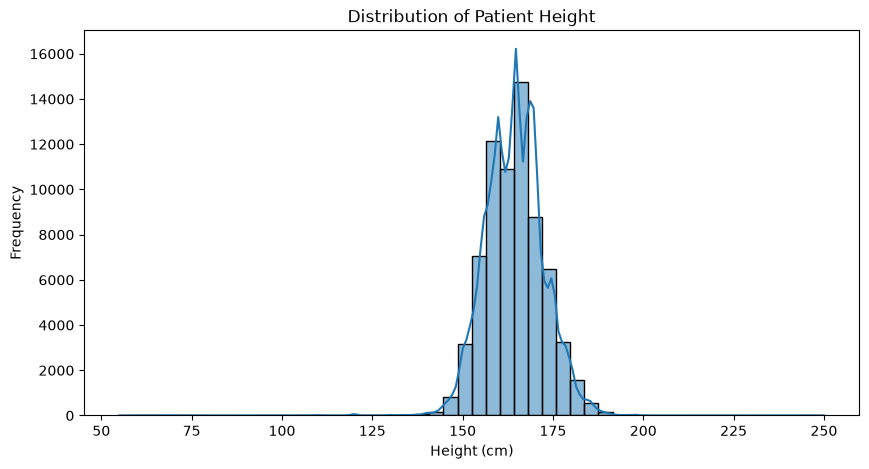

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(df["height"], bins=50, kde=True)
plt.title("Distribution of Patient Height")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.show()

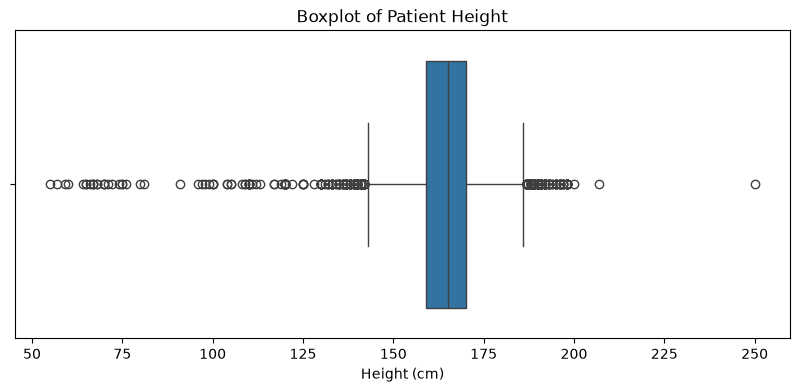

In [24]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["height"])
plt.title("Boxplot of Patient Height")
plt.xlabel("Height (cm)")
plt.show()

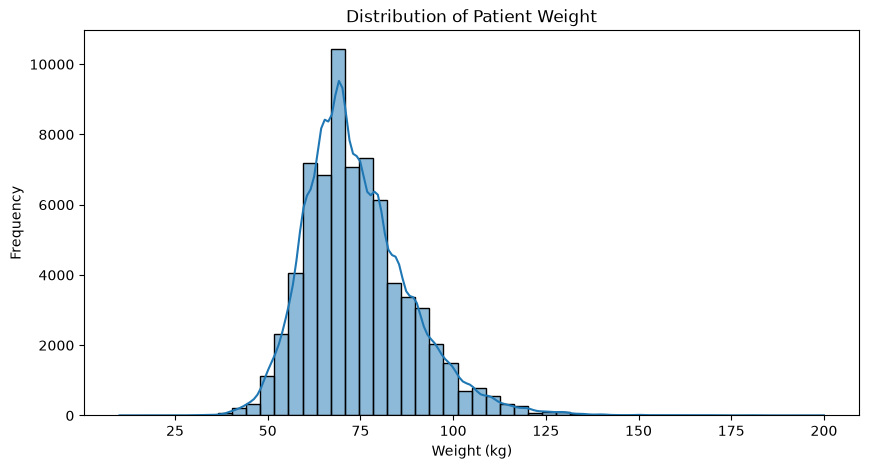

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df["weight"], bins=50, kde=True)
plt.title("Distribution of Patient Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.show()

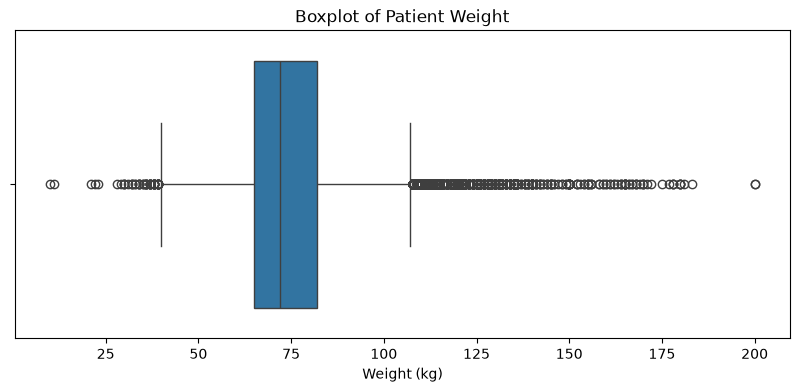

In [26]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["weight"])
plt.title("Boxplot of Patient Weight")
plt.xlabel("Weight (kg)")
plt.show()

In [27]:
print("Systolic BP <= 0:", (df["ap_hi"] <= 0).sum())
print("Systolic BP < 80:", (df["ap_hi"] < 80).sum())
print("Systolic BP > 250:", (df["ap_hi"] > 250).sum())

print()

print("Diastolic BP <= 0:", (df["ap_lo"] <= 0).sum())
print("Diastolic BP < 40:", (df["ap_lo"] < 40).sum())
print("Diastolic BP > 150:", (df["ap_lo"] > 150).sum())

Systolic BP <= 0: 7
Systolic BP < 80: 207
Systolic BP > 250: 40

Diastolic BP <= 0: 22
Diastolic BP < 40: 59
Diastolic BP > 150: 975


In [28]:
print("Lowest systolic BP values:")
print(df["ap_hi"].sort_values().head(20).to_list())

print("\nHighest systolic BP values:")
print(df["ap_hi"].sort_values(ascending=False).head(20).to_list())

print("\nLowest diastolic BP values:")
print(df["ap_lo"].sort_values().head(20).to_list())

print("\nHighest diastolic BP values:")
print(df["ap_lo"].sort_values(ascending=False).head(20).to_list())

Lowest systolic BP values:
[-150.0, -140.0, -120.0, -120.0, -115.0, -100.0, -100.0, 1.0, 1.0, 7.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 11.0, 11.0, 11.0]

Highest systolic BP values:
[16020.0, 14020.0, 14020.0, 14020.0, 14020.0, 13010.0, 13010.0, 11500.0, 11020.0, 2000.0, 1620.0, 1500.0, 1420.0, 1420.0, 1409.0, 1400.0, 1400.0, 1400.0, 1300.0, 1300.0]

Lowest diastolic BP values:
[-70.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Highest diastolic BP values:
[11000.0, 10000.0, 10000.0, 10000.0, 9800.0, 9100.0, 9011.0, 9011.0, 8500.0, 8200.0, 8100.0, 8099.0, 8099.0, 8099.0, 8079.0, 8077.0, 8044.0, 8000.0, 8000.0, 7100.0]


In [29]:
invalid_bp_order = df[df["ap_hi"] <= df["ap_lo"]]

print("Records where systolic <= diastolic:")
print(len(invalid_bp_order))

print("\nPercentage of dataset:")
print(len(invalid_bp_order) / len(df) * 100)

Records where systolic <= diastolic:
1236

Percentage of dataset:
1.7657142857142858


In [30]:
invalid_bp_order[
    ["age", "gender", "ap_hi", "ap_lo", "cardio"]
].head(20)

,age,gender,ap_hi,ap_lo,cardio
228,47.882272,1,160.0,1100.0,1
241,60.046543,1,160.0,1000.0,1
260,49.875428,0,140.0,800.0,1
329,64.084873,0,160.0,1000.0,1
345,51.208761,0,140.0,1000.0,1
473,41.686516,0,150.0,1033.0,1
474,52.290212,0,120.0,150.0,0
559,55.934292,1,200.0,1000.0,1
567,58.264203,0,14.0,90.0,1
613,51.917864,0,140.0,1000.0,1


In [31]:
bp_invalid = (
    (df["ap_hi"] < 80) |
    (df["ap_hi"] > 250) |
    (df["ap_lo"] < 40) |
    (df["ap_lo"] > 150) |
    (df["ap_hi"] <= df["ap_lo"])
)

print("Invalid BP records:", bp_invalid.sum())
print("Valid BP records:", (~bp_invalid).sum())
print("Percent removed:", bp_invalid.mean() * 100)
print("Percent retained:", (~bp_invalid).mean() * 100)

Invalid BP records: 1338
Valid BP records: 68662
Percent removed: 1.9114285714285715
Percent retained: 98.08857142857143


In [32]:
df_raw = df.copy()

In [33]:
df = df[~bp_invalid].copy()

In [34]:
df.reset_index(drop=True, inplace=True)

In [35]:
print("Original shape:", df_raw.shape)
print("Cleaned shape:", df.shape)

print("\nCleaned BP summary:")
print(df[["ap_hi", "ap_lo"]].describe())

print("\nRemaining systolic <= diastolic:",
      (df["ap_hi"] <= df["ap_lo"]).sum())

Original shape: (70000, 12)
Cleaned shape: (68662, 12)

Cleaned BP summary:
              ap_hi         ap_lo
count  68662.000000  68662.000000
mean     126.672832     81.303603
std       16.675589      9.419067
min       80.000000     40.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max      240.000000    150.000000

Remaining systolic <= diastolic: 0


In [36]:
df_raw = df.copy()

In [37]:
df = df[~bp_invalid].copy()

C:\Users\James\AppData\Local\Temp\ipykernel_53080\2829294645.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[~bp_invalid].copy()


In [38]:
df.reset_index(drop=True, inplace=True)

In [39]:
print("Original shape:", df_raw.shape)
print("Cleaned shape:", df.shape)

print("\nCleaned BP summary:")
print(df[["ap_hi", "ap_lo"]].describe())

print("\nRemaining systolic <= diastolic:",
      (df["ap_hi"] <= df["ap_lo"]).sum())

Original shape: (68662, 12)
Cleaned shape: (67352, 12)

Cleaned BP summary:
              ap_hi         ap_lo
count  67352.000000  67352.000000
mean     126.681316     81.308989
std       16.676575      9.416364
min       80.000000     40.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max      240.000000    150.000000

Remaining systolic <= diastolic: 0


In [40]:
df = pd.read_csv("health_data.csv")

df = df.drop(columns=["Unnamed: 0", "id"])

df["age"] = df["age"] / 365.25

print(df.shape)

(70000, 12)


In [41]:
df_raw = df.copy()

In [42]:
bp_invalid = (
    (df["ap_hi"] < 80) |
    (df["ap_hi"] > 250) |
    (df["ap_lo"] < 40) |
    (df["ap_lo"] > 150) |
    (df["ap_hi"] <= df["ap_lo"])
)

print("Invalid BP records:", bp_invalid.sum())

Invalid BP records: 1338


In [43]:
df = df.loc[~bp_invalid].copy()
df.reset_index(drop=True, inplace=True)

print("Raw shape:", df_raw.shape)
print("Cleaned shape:", df.shape)

Raw shape: (70000, 12)
Cleaned shape: (68662, 12)


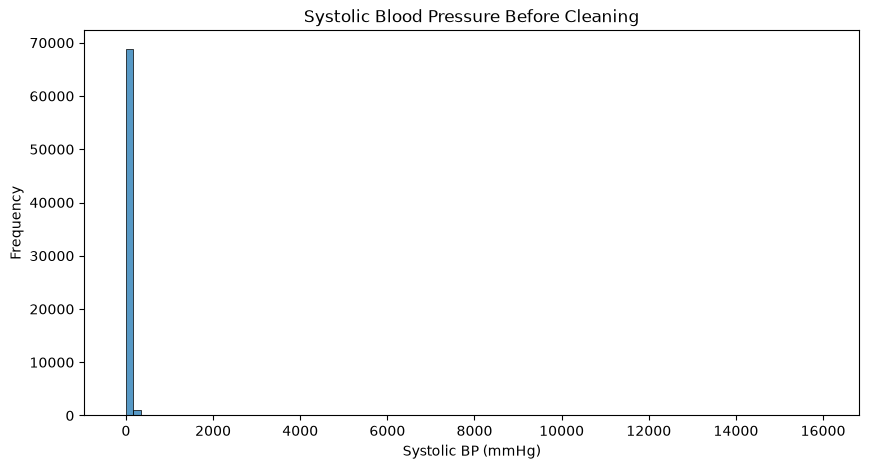

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(df_raw["ap_hi"], bins=100, kde=False)
plt.title("Systolic Blood Pressure Before Cleaning")
plt.xlabel("Systolic BP (mmHg)")
plt.ylabel("Frequency")
plt.show()

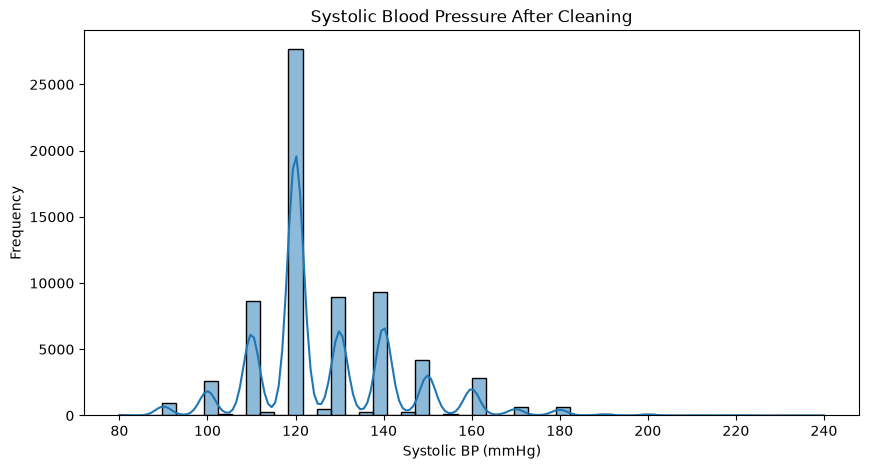

In [45]:
plt.figure(figsize=(10, 5))
sns.histplot(df["ap_hi"], bins=50, kde=True)
plt.title("Systolic Blood Pressure After Cleaning")
plt.xlabel("Systolic BP (mmHg)")
plt.ylabel("Frequency")
plt.show()

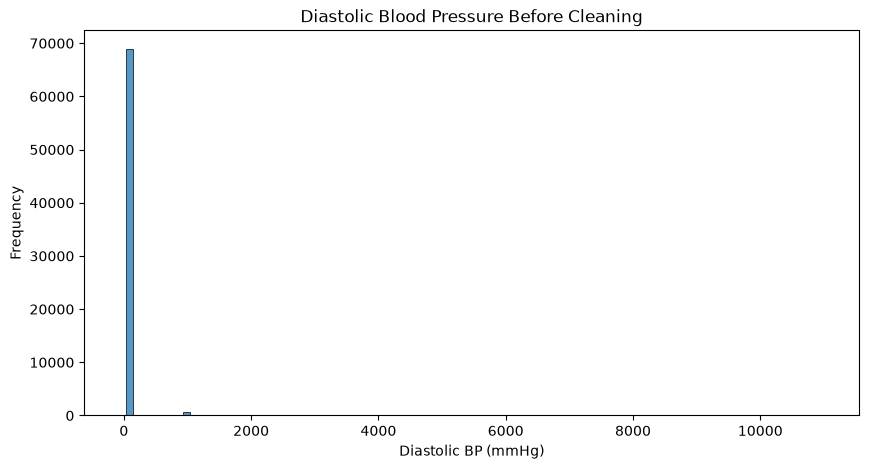

In [46]:
plt.figure(figsize=(10, 5))
sns.histplot(df_raw["ap_lo"], bins=100, kde=False)
plt.title("Diastolic Blood Pressure Before Cleaning")
plt.xlabel("Diastolic BP (mmHg)")
plt.ylabel("Frequency")
plt.show()

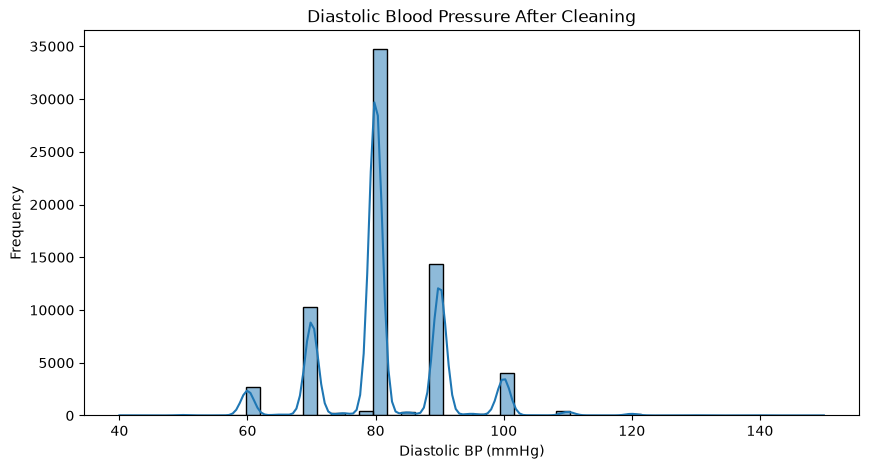

In [47]:
plt.figure(figsize=(10, 5))
sns.histplot(df["ap_lo"], bins=50, kde=True)
plt.title("Diastolic Blood Pressure After Cleaning")
plt.xlabel("Diastolic BP (mmHg)")
plt.ylabel("Frequency")
plt.show()

In [48]:
bmi_preview = df["weight"] / ((df["height"] / 100) ** 2)

bmi_preview.describe()

count    68662.000000
mean        27.521825
std          6.051845
min          3.471784
25%         23.875115
50%         26.346494
75%         30.119376
max        298.666667
dtype: float64

In [49]:
print("BMI below 10:", (bmi_preview < 10).sum())
print("BMI above 60:", (bmi_preview > 60).sum())

print("\nLowest BMI values:")
print(bmi_preview.sort_values().head(10).to_list())

print("\nHighest BMI values:")
print(bmi_preview.sort_values(ascending=False).head(10).to_list())

BMI below 10: 5
BMI above 60: 61

Lowest BMI values:
[3.471783865673526, 7.022247757668613, 8.00182898948331, 9.331007343097083, 9.917581478061626, 10.726643598615919, 11.718749999999998, 12.254472882602151, 12.85583103764922, 13.493000505987519]

Highest BMI values:
[298.6666666666667, 278.12499999999994, 267.76859504132227, 237.76863283036118, 191.66666666666669, 187.75007694675287, 180.67807418429163, 178.9627465303141, 178.21341055914453, 170.41420118343194]


## 5. Feature Engineering and BMI Investigation

Body Mass Index (BMI) is engineered from height and weight using the standard relationship:

\[
BMI = \frac{weight\ (kg)}{height\ (m)^2}
\]

BMI provides a normalized measure of body mass relative to height and may contain predictive information that is not captured by height or weight alone.

Before using BMI for modeling, extreme BMI values are investigated because implausible height or weight measurements can produce highly unrealistic BMI values. This step therefore also serves as an additional data-quality check before the final modeling dataset is constructed.

In [50]:
# Create BMI temporarily for investigation
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# Examine extremely low BMI records
print("=== LOWEST BMI RECORDS ===")
display(
    df.sort_values("bmi")[
        ["age", "gender", "height", "weight", "bmi", "cardio"]
    ].head(15)
)

# Examine extremely high BMI records
print("\n=== HIGHEST BMI RECORDS ===")
display(
    df.sort_values("bmi", ascending=False)[
        ["age", "gender", "height", "weight", "bmi", "cardio"]
    ].head(20)
)

=== LOWEST BMI RECORDS ===


,age,gender,height,weight,bmi,cardio
33164,59.088296,1,178.0,11.0,3.471784,1
28914,55.874059,1,177.0,22.0,7.022248,0
59042,59.835729,0,162.0,21.0,8.001829,1
26280,63.748118,0,157.0,23.0,9.331007,0
59539,51.676934,0,171.0,29.0,9.917581,1
16584,47.288159,1,170.0,31.0,10.726644,1
18197,49.664613,0,160.0,30.0,11.718750,1
57092,61.722108,0,169.0,35.0,12.254473,1
16007,59.882272,0,165.0,35.0,12.855831,0
37679,59.709788,0,154.0,32.0,13.493001,0



=== HIGHEST BMI RECORDS ===


,age,gender,height,weight,bmi,cardio
12520,53.645448,0,75.0,168.0,298.666667,1
26849,41.867214,0,80.0,178.0,278.125000,1
22278,64.027379,0,55.0,81.0,267.768595,1
23447,52.221766,0,81.0,156.0,237.768633,0
28588,52.260096,0,60.0,69.0,191.666667,0
65375,51.553730,0,57.0,61.0,187.750077,1
8004,48.312115,1,97.0,170.0,180.678074,1
16378,53.880903,1,74.0,98.0,178.962747,1
52333,56.238193,1,67.0,80.0,178.213411,1
32957,53.960301,1,65.0,72.0,170.414201,0


In [51]:
# Investigate physiologically implausible height and weight values

print("=== HEIGHT QUALITY ===")
print("Height < 120 cm:", (df["height"] < 120).sum())
print("Height > 220 cm:", (df["height"] > 220).sum())

print("\n=== WEIGHT QUALITY ===")
print("Weight < 30 kg:", (df["weight"] < 30).sum())
print("Weight > 200 kg:", (df["weight"] > 200).sum())

# Combined invalid anthropometric records
anthro_invalid = (
    (df["height"] < 120) |
    (df["height"] > 220) |
    (df["weight"] < 30) |
    (df["weight"] > 200)
)

print("\n=== COMBINED ===")
print("Invalid anthropometric records:", anthro_invalid.sum())
print("Valid records:", (~anthro_invalid).sum())
print("Percent affected:", anthro_invalid.mean() * 100)

=== HEIGHT QUALITY ===
Height < 120 cm: 49
Height > 220 cm: 1

=== WEIGHT QUALITY ===
Weight < 30 kg: 6
Weight > 200 kg: 0

=== COMBINED ===
Invalid anthropometric records: 56
Valid records: 68606
Percent affected: 0.08155894089889605


In [52]:
# ---------------------------------------------------------
# CLEANING STEP 2: HEIGHT AND WEIGHT
# ---------------------------------------------------------

# Save size before anthropometric cleaning
before_anthro = len(df)

# Define implausible anthropometric measurements
anthro_invalid = (
    (df["height"] < 120) |
    (df["height"] > 220) |
    (df["weight"] < 30) |
    (df["weight"] > 200)
)

# Remove invalid records
df = df.loc[~anthro_invalid].copy()
df.reset_index(drop=True, inplace=True)

# Calculate removal statistics
after_anthro = len(df)
removed_anthro = before_anthro - after_anthro

print("Before anthropometric cleaning:", before_anthro)
print("After anthropometric cleaning:", after_anthro)
print("Records removed:", removed_anthro)
print("Percent removed:", removed_anthro / before_anthro * 100)

print("\nRemaining height range:")
print(df["height"].min(), "to", df["height"].max(), "cm")

print("\nRemaining weight range:")
print(df["weight"].min(), "to", df["weight"].max(), "kg")

Before anthropometric cleaning: 68662
After anthropometric cleaning: 68606
Records removed: 56
Percent removed: 0.08155894089889605

Remaining height range:
120.0 to 207.0 cm

Remaining weight range:
30.0 to 200.0 kg


In [53]:
# ---------------------------------------------------------
# FEATURE ENGINEERING: BODY MASS INDEX (BMI)
# ---------------------------------------------------------

df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

print(df["bmi"].describe())

print("\nLowest BMI values:")
print(df["bmi"].nsmallest(10).tolist())

print("\nHighest BMI values:")
print(df["bmi"].nlargest(10).tolist())

count    68606.000000
mean        27.457792
std          5.256995
min         10.726644
25%         23.875115
50%         26.346494
75%         30.118585
max        108.169847
Name: bmi, dtype: float64

Lowest BMI values:
[10.726643598615919, 11.718749999999998, 12.254472882602151, 12.85583103764922, 13.493000505987519, 13.520822065981614, 14.479500076207893, 14.524328249818446, 14.527376033057852, 14.57725947521866]

Highest BMI values:
[108.16984681537221, 106.88, 85.77974319356385, 69.53473910339758, 68.30831506156181, 67.84599375650363, 65.38108356290175, 65.38108356290175, 65.35672120087705, 65.26640560104426]


In [54]:
# ---------------------------------------------------------
# INVESTIGATE REMAINING BMI EXTREMES
# ---------------------------------------------------------

print("=== VERY LOW BMI RECORDS (BMI < 15) ===")
display(
    df.loc[df["bmi"] < 15,
           ["age", "gender", "height", "weight", "bmi", "cardio"]]
      .sort_values("bmi")
)

print("\n=== VERY HIGH BMI RECORDS (BMI > 60) ===")
display(
    df.loc[df["bmi"] > 60,
           ["age", "gender", "height", "weight", "bmi", "cardio"]]
      .sort_values("bmi", ascending=False)
)

print("\nNumber with BMI < 15:", (df["bmi"] < 15).sum())
print("Number with BMI > 60:", (df["bmi"] > 60).sum())

=== VERY LOW BMI RECORDS (BMI < 15) ===


,age,gender,height,weight,bmi,cardio
16572,47.288159,1,170.0,31.0,10.726644,1
18184,49.664613,0,160.0,30.0,11.718750,1
57048,61.722108,0,169.0,35.0,12.254473,1
15996,59.882272,0,165.0,35.0,12.855831,0
37648,59.709788,0,154.0,32.0,13.493001,0
9283,57.379877,1,172.0,40.0,13.520822,1
10223,60.251882,0,162.0,38.0,14.479500,0
32837,57.716632,0,153.0,34.0,14.524328,1
31952,52.038330,0,176.0,45.0,14.527376,1
15900,53.719370,0,196.0,56.0,14.577259,0



=== VERY HIGH BMI RECORDS (BMI > 60) ===


,age,gender,height,weight,bmi,cardio
6021,57.467488,0,122.0,161.0,108.169847,1
15059,47.652293,0,125.0,167.0,106.880000,1
12183,60.443532,0,137.0,161.0,85.779743,1
66515,59.583847,0,133.0,123.0,69.534739,1
39904,59.488022,0,154.0,162.0,68.308315,0
18567,42.220397,0,155.0,163.0,67.845994,1
19681,56.553046,1,165.0,178.0,65.381084,0
60559,51.898700,1,165.0,178.0,65.381084,0
62426,64.292950,0,154.0,155.0,65.356721,0
2407,64.739220,1,159.0,165.0,65.266406,0



Number with BMI < 15: 20
Number with BMI > 60: 23


## 6. Reproducible Modeling Dataset

After investigating the raw data and identifying appropriate cleaning rules, the dataset is rebuilt from the original source to create a reproducible modeling pipeline.

A separate dataframe, `df_rep`, is used so that the final preprocessing steps can be reproduced independently of the earlier exploratory analysis.

In [55]:
# ============================================================
# PHASE 2: GITHUB REPLICATION PIPELINE
# ============================================================

df_rep = pd.read_csv("health_data.csv")

print("Original replication dataset shape:", df_rep.shape)

Original replication dataset shape: (70000, 14)


In [56]:
print("Replication dataset shape:", df_rep.shape)

print("\nColumns:")
print(df_rep.columns.tolist())

Replication dataset shape: (70000, 14)

Columns:
['Unnamed: 0', 'id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [57]:
# ============================================================
# GITHUB REPLICATION - DATA CLEANING
# ============================================================

# 1. Remove the exported CSV index column
df_rep = df_rep.drop(columns=["Unnamed: 0"])

print("After dropping 'Unnamed: 0':", df_rep.shape)

# 2. Clean blood-pressure measurements
df_rep = df_rep[
    (df_rep["ap_hi"] >= 30) &
    (df_rep["ap_hi"] <= 300) &
    (df_rep["ap_lo"] >= 30) &
    (df_rep["ap_lo"] <= 300)
]

print("After BP cleaning:", df_rep.shape)

# 3. Clean height measurements
df_rep = df_rep[
    (df_rep["height"] >= 100) &
    (df_rep["height"] <= 250)
]

print("After height cleaning:", df_rep.shape)

# 4. Clean weight measurements
df_rep = df_rep[
    (df_rep["weight"] >= 20) &
    (df_rep["weight"] <= 200)
]

print("After weight cleaning:", df_rep.shape)

After dropping 'Unnamed: 0': (70000, 13)
After BP cleaning: (68781, 13)
After height cleaning: (68755, 13)
After weight cleaning: (68754, 13)


In [58]:
# ============================================================
# GITHUB REPLICATION - FEATURE ENGINEERING
# ============================================================

# Convert age from days to years
df_rep["age"] = df_rep["age"] / 365.25

# Convert height from centimeters to meters
df_rep["height"] = df_rep["height"] / 100

# Create BMI
df_rep["bmi"] = df_rep["weight"] / (df_rep["height"] ** 2)

print("Dataset shape:", df_rep.shape)

print("\nAge summary:")
print(df_rep["age"].describe())

print("\nHeight summary:")
print(df_rep["height"].describe())

print("\nBMI summary:")
print(df_rep["bmi"].describe())

Dataset shape: (68754, 14)

Age summary:
count    68754.000000
mean        53.291148
std          6.757067
min         29.563313
25%         48.342916
50%         53.938398
75%         58.381930
max         64.922656
Name: age, dtype: float64

Height summary:
count    68754.000000
mean         1.643962
std          0.079865
min          1.000000
25%          1.590000
50%          1.650000
75%          1.700000
max          2.500000
Name: height, dtype: float64

BMI summary:
count    68754.000000
mean        27.473290
std          5.352965
min          7.022248
25%         23.875115
50%         26.346494
75%         30.119376
max        152.551775
Name: bmi, dtype: float64


In [59]:
# ============================================================
# GITHUB REPLICATION - CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df_rep.corr(numeric_only=True)

# Show correlations with the target variable
cardio_correlations = (
    correlation_matrix["cardio"]
    .sort_values(ascending=False)
)

print("Correlation with cardiovascular disease:")
print(cardio_correlations)

Correlation with cardiovascular disease:
cardio         1.000000
ap_hi          0.425087
ap_lo          0.334558
age            0.239547
cholesterol    0.221552
bmi            0.186139
weight         0.179747
gluc           0.090061
gender         0.007246
id             0.003792
alco          -0.008170
height        -0.011837
smoke         -0.016357
active        -0.037412
Name: cardio, dtype: float64


In [60]:
print("Correlation between BMI and weight:",
      df_rep["bmi"].corr(df_rep["weight"]))

print("Correlation between BMI and height:",
      df_rep["bmi"].corr(df_rep["height"]))

Correlation between BMI and weight: 0.8510973518408351
Correlation between BMI and height: -0.22370664091850215


## 7. Modeling Preparation

The cleaned replication dataset is prepared for supervised machine learning.

The patient identifier (`id`) is removed because it does not provide meaningful predictive information. The target variable is `cardio`, where `0` represents absence of cardiovascular disease and `1` represents presence of cardiovascular disease.

The remaining 12 variables are used as predictors. The dataset is divided into training and test sets using an 80/20 stratified split so that the nearly balanced target distribution is preserved in both subsets.

In [61]:
# ============================================================
# GITHUB REPLICATION - PREPARE MODELING DATA
# ============================================================

# Remove patient identifier
df_rep_model = df_rep.drop(columns=["id"]).copy()

print("Modeling dataset shape:", df_rep_model.shape)

print("\nModeling columns:")
print(df_rep_model.columns.tolist())

print("\nTarget distribution:")
print(df_rep_model["cardio"].value_counts())

print("\nTarget percentages:")
print(
    df_rep_model["cardio"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Modeling dataset shape: (68754, 13)

Modeling columns:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi']

Target distribution:
cardio
0    34726
1    34028
Name: count, dtype: int64

Target percentages:
cardio
0    50.51
1    49.49
Name: proportion, dtype: float64


In [62]:
# ============================================================
# GITHUB REPLICATION - DEFINE X AND y
# ============================================================

X = df_rep_model.drop(columns=["cardio"])
y = df_rep_model["cardio"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used for prediction:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (68754, 12)
y shape: (68754,)

Features used for prediction:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']

Target:
cardio


In [63]:
# ============================================================
# GITHUB REPLICATION - TRAIN/TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train shape: (55003, 12)
X_test shape: (13751, 12)
y_train shape: (55003,)
y_test shape: (13751,)

Training target distribution (%):
cardio
0    50.51
1    49.49
Name: proportion, dtype: float64

Test target distribution (%):
cardio
0    50.51
1    49.49
Name: proportion, dtype: float64


## 8. Baseline Model Comparison

Three classification algorithms are evaluated as baseline models:

- Logistic Regression
- Random Forest
- XGBoost

Performance is assessed using accuracy, precision, recall, F1 score, ROC-AUC, confusion matrices, and classification reports.

Using multiple metrics is important because cardiovascular-risk prediction involves a trade-off between identifying positive cases and limiting false-positive predictions.

In [64]:
# ============================================================
# BASELINE MODEL - LOGISTIC REGRESSION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Create preprocessing + model pipeline
# ------------------------------------------------------------

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# ------------------------------------------------------------
# 2. Train ONLY on training data
# ------------------------------------------------------------

logistic_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 3. Predict on unseen test data
# ------------------------------------------------------------

y_pred = logistic_model.predict(X_test)

# Probability of cardiovascular disease
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 4. Evaluate
# ------------------------------------------------------------

print("=== LOGISTIC REGRESSION BASELINE ===")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPrecision:")
print(precision_score(y_test, y_pred))

print("\nRecall:")
print(recall_score(y_test, y_pred))

print("\nF1 Score:")
print(f1_score(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== LOGISTIC REGRESSION BASELINE ===

Accuracy:
0.7268562286379172

Precision:
0.7531540504648074

Recall:
0.6666176902732883

F1 Score:
0.7072486360093531

ROC-AUC:
0.7906200474870032

Confusion Matrix:
[[5458 1487]
 [2269 4537]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.74      6945
           1       0.75      0.67      0.71      6806

    accuracy                           0.73     13751
   macro avg       0.73      0.73      0.73     13751
weighted avg       0.73      0.73      0.73     13751



In [65]:
# ============================================================
# RANDOM FOREST BASELINE
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Create Random Forest
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

rf_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 3. Predict
# ------------------------------------------------------------

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 4. Evaluate
# ------------------------------------------------------------

print("=== RANDOM FOREST BASELINE ===")

print("\nAccuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nPrecision:")
print(precision_score(y_test, rf_pred))

print("\nRecall:")
print(recall_score(y_test, rf_pred))

print("\nF1 Score:")
print(f1_score(y_test, rf_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== RANDOM FOREST BASELINE ===

Accuracy:
0.7182750345429423

Precision:
0.7227286539045883

Recall:
0.6989421099030267

F1 Score:
0.7106363907977293

ROC-AUC:
0.7780507374279291

Confusion Matrix:
[[5120 1825]
 [2049 4757]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.73      6945
           1       0.72      0.70      0.71      6806

    accuracy                           0.72     13751
   macro avg       0.72      0.72      0.72     13751
weighted avg       0.72      0.72      0.72     13751



In [66]:
#%pip install xgboost

In [67]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [68]:
# ============================================================
# XGBOOST BASELINE
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create baseline XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=== XGBOOST BASELINE ===")

print("\nAccuracy:")
print(accuracy_score(y_test, xgb_pred))

print("\nPrecision:")
print(precision_score(y_test, xgb_pred))

print("\nRecall:")
print(recall_score(y_test, xgb_pred))

print("\nF1 Score:")
print(f1_score(y_test, xgb_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

=== XGBOOST BASELINE ===

Accuracy:
0.7344920369427678

Precision:
0.7551350477114669

Recall:
0.6860123420511314

F1 Score:
0.7189160058511048

ROC-AUC:
0.802215943794141

Confusion Matrix:
[[5431 1514]
 [2137 4669]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6945
           1       0.76      0.69      0.72      6806

    accuracy                           0.73     13751
   macro avg       0.74      0.73      0.73     13751
weighted avg       0.74      0.73      0.73     13751



## 9. Cross-Validation and Hyperparameter Tuning

Five-fold cross-validation is used to evaluate model stability and reduce reliance on a single train/test split.

XGBoost is also tuned using randomized hyperparameter search. Parameters such as tree depth, learning rate, number of estimators, subsampling, column sampling, and minimum child weight are explored.

The tuned model does not materially outperform the baseline XGBoost model, so the simpler baseline configuration is retained as the final model.

In [69]:
# ============================================================
# 5-FOLD CROSS-VALIDATION
# ============================================================

import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("XGBoost ROC-AUC for each fold:")
print(xgb_cv_scores)

print("\nMean ROC-AUC:")
print(xgb_cv_scores.mean())

print("\nStandard deviation:")
print(xgb_cv_scores.std())

XGBoost ROC-AUC for each fold:
[0.80232652 0.8039554  0.79569739 0.7998474  0.80485952]

Mean ROC-AUC:
0.8013372475310128

Standard deviation:
0.0032944641449193547


In [70]:
# ============================================================
# XGBOOST HYPERPARAMETER TUNING - RANDOMIZED SEARCH
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Base XGBoost model
xgb_tuning_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=1
)

# Candidate hyperparameters
param_distributions = {
    "n_estimators": [150, 250, 350, 450, 600],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.8, 'n_estimators': 350, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best cross-validation ROC-AUC:
0.801252948527449


In [71]:
# ============================================================
# CROSS-VALIDATION MODEL COMPARISON
# ============================================================

from sklearn.model_selection import cross_val_score

# Logistic Regression
logistic_cv = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Random Forest
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Baseline XGBoost
xgb_cv = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("=== 5-FOLD CROSS-VALIDATION COMPARISON ===")

print(
    f"\nLogistic Regression: "
    f"{logistic_cv.mean():.6f} ± {logistic_cv.std():.6f}"
)

print(
    f"Random Forest:       "
    f"{rf_cv.mean():.6f} ± {rf_cv.std():.6f}"
)

print(
    f"XGBoost:             "
    f"{xgb_cv.mean():.6f} ± {xgb_cv.std():.6f}"
)

print(
    f"Tuned XGBoost:       "
    f"{random_search.best_score_:.6f}"
)

=== 5-FOLD CROSS-VALIDATION COMPARISON ===

Logistic Regression: 0.790255 ± 0.003769
Random Forest:       0.773915 ± 0.003576
XGBoost:             0.801337 ± 0.003294
Tuned XGBoost:       0.801253


## 10. Final Model Evaluation

Based on baseline performance and cross-validation results, XGBoost is selected as the final classifier.

The final model is evaluated on the held-out test set, which was not used for model fitting.

Final test performance:

- Accuracy: 73.45%
- Precision: 75.51%
- Recall: 68.60%
- F1 Score: 71.89%
- ROC-AUC: 80.22%

The ROC-AUC indicates that the model has useful discriminatory ability, although the results should not be interpreted as clinical validation.

In [72]:
# ============================================================
# FINAL MODEL EVALUATION - XGBOOST
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Final predictions
final_pred = xgb_model.predict(X_test)
final_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_auc = roc_auc_score(y_test, final_prob)

print("=== FINAL XGBOOST MODEL ===")

print(f"\nAccuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1 Score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

=== FINAL XGBOOST MODEL ===

Accuracy:  0.7345
Precision: 0.7551
Recall:    0.6860
F1 Score:  0.7189
ROC-AUC:   0.8022

Confusion Matrix:
[[5431 1514]
 [2137 4669]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6945
           1       0.76      0.69      0.72      6806

    accuracy                           0.73     13751
   macro avg       0.74      0.73      0.73     13751
weighted avg       0.74      0.73      0.73     13751



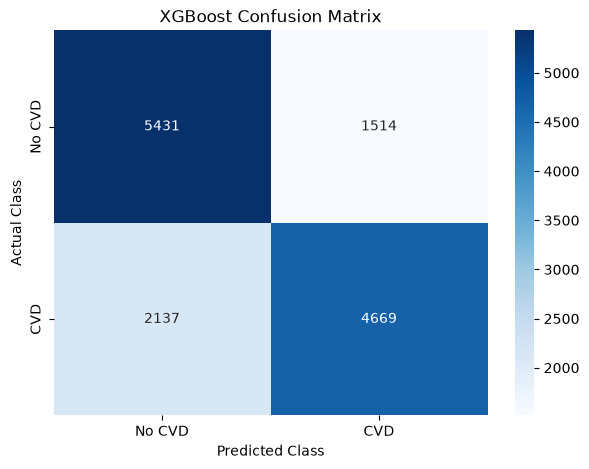

In [73]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No CVD", "CVD"],
    yticklabels=["No CVD", "CVD"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

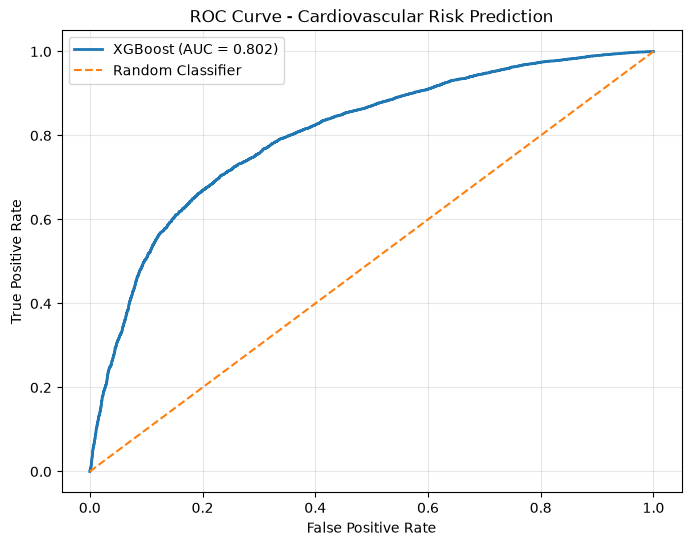

In [74]:
# ============================================================
# ROC CURVE - FINAL XGBOOST MODEL
# ============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, final_prob)

# Calculate area under curve
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cardiovascular Risk Prediction")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 11. Feature Importance and Decision Threshold Analysis

Feature importance is examined to understand which variables contribute most strongly to the XGBoost model.

The default classification threshold of 0.50 is also compared with alternative thresholds. Lower thresholds increase recall but generate more false positives, while higher thresholds improve precision but increase false negatives.

This illustrates an important practical consideration: the optimal threshold depends on the relative cost of missing true cardiovascular-disease cases versus incorrectly flagging healthy individuals.

In [75]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

        Feature  Importance
4         ap_hi    0.403439
5         ap_lo    0.185838
6   cholesterol    0.156549
0           age    0.071215
10       active    0.038655
8         smoke    0.028873
7          gluc    0.027197
11          bmi    0.022677
9          alco    0.020407
3        weight    0.018745
1        gender    0.014516
2        height    0.011889


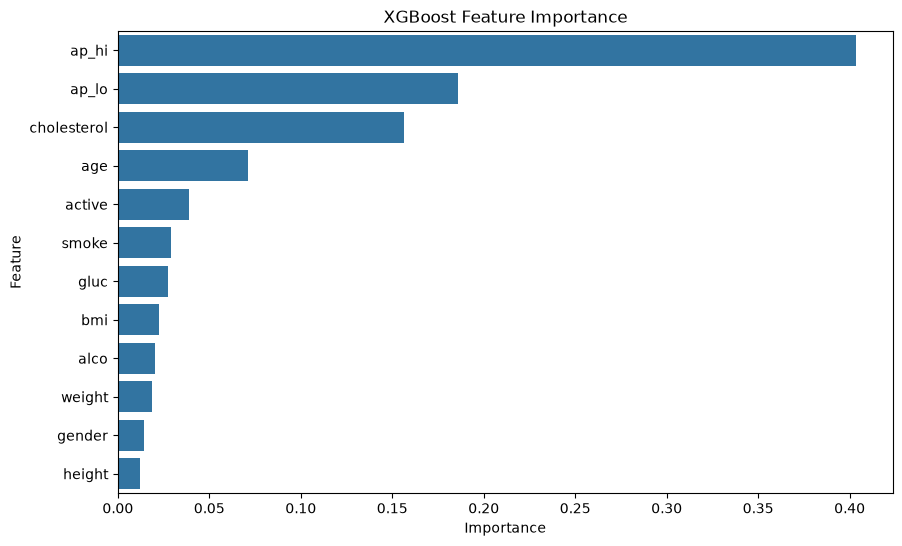

In [76]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [77]:
# ============================================================
# CLASSIFICATION THRESHOLD ANALYSIS
# ============================================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds_to_test:

    predictions = (final_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "True Negatives": tn
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives,True Positives,True Negatives
0,0.30,0.6800,0.6261,0.8776,0.7308,3567,833,5973,3378
1,0.35,0.7095,0.6641,0.8356,0.7401,2876,1119,5687,4069
2,0.40,0.7279,0.7033,0.7790,0.7392,2237,1504,5302,4708
3,0.45,0.7339,0.7305,0.7327,0.7316,1840,1819,4987,5105
4,0.50,0.7345,0.7551,0.6860,0.7189,1514,2137,4669,5431
5,0.55,0.7323,0.7809,0.6383,0.7024,1219,2462,4344,5726
6,0.60,0.7266,0.8034,0.5927,0.6822,987,2772,4034,5958
7,0.65,0.7189,0.8224,0.5510,0.6599,810,3056,3750,6135
8,0.70,0.7083,0.8308,0.5157,0.6364,715,3296,3510,6230


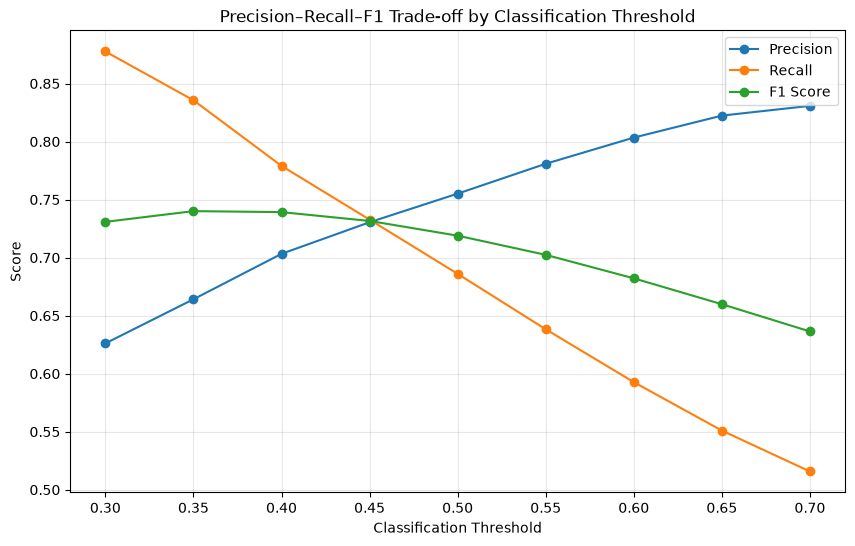

In [78]:
# ============================================================
# THRESHOLD TRADE-OFF VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall–F1 Trade-off by Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [79]:
#%pip install shap

In [80]:
#import sys
#print(sys.executable)

In [81]:
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
import shap

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("SHAP:", shap.__version__)

NumPy: 2.4.6
Pandas: 3.0.5
Scikit-learn: 1.9.0
XGBoost: 3.2.0
SHAP: 0.51.0


C:\Users\James\anaconda3\envs\cardio-risk-clean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [82]:
# ============================================================
# RESTORE CARDIO RISK REPLICATION / MODELING STATE
# ============================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. Reload raw data
# ------------------------------------------------------------

df_rep = pd.read_csv("health_data.csv")

# ------------------------------------------------------------
# 2. Replicate GitHub cleaning
# ------------------------------------------------------------

df_rep = df_rep.drop(columns=["Unnamed: 0"])

df_rep = df_rep[
    (df_rep["ap_hi"] >= 30) &
    (df_rep["ap_hi"] <= 300) &
    (df_rep["ap_lo"] >= 30) &
    (df_rep["ap_lo"] <= 300)
]

df_rep = df_rep[
    (df_rep["height"] >= 100) &
    (df_rep["height"] <= 250)
]

df_rep = df_rep[
    (df_rep["weight"] >= 20) &
    (df_rep["weight"] <= 200)
]

# ------------------------------------------------------------
# 3. Feature engineering
# ------------------------------------------------------------

df_rep["age"] = df_rep["age"] / 365.25
df_rep["height"] = df_rep["height"] / 100
df_rep["bmi"] = df_rep["weight"] / (df_rep["height"] ** 2)

# ------------------------------------------------------------
# 4. Prepare modeling dataset
# ------------------------------------------------------------

df_rep_model = df_rep.drop(columns=["id"]).copy()

X = df_rep_model.drop(columns=["cardio"])
y = df_rep_model["cardio"]

# ------------------------------------------------------------
# 5. Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 6. Restore selected XGBoost model
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

# Generate predictions and probabilities
final_pred = xgb_model.predict(X_test)
final_prob = xgb_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 7. Verify restored state
# ------------------------------------------------------------

print("df_rep shape:", df_rep.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Model restored successfully.")

df_rep shape: (68754, 14)
X_train shape: (55003, 12)
X_test shape: (13751, 12)
Model restored successfully.


## 12. SHAP Model Explainability

SHAP (SHapley Additive exPlanations) is used to interpret the final XGBoost model.

The analysis includes both:

- Global explanations, showing which variables influence predictions across the dataset
- Local explanations, showing why the model produced a specific prediction for an individual patient

SHAP values indicate whether each feature pushes a prediction toward higher or lower modeled cardiovascular risk.

A sample of 2,000 test observations is used for the global SHAP analysis to provide interpretable visualizations while keeping computation manageable.

In [83]:
# ============================================================
# SHAP EXPLAINABILITY - GLOBAL FEATURE EFFECTS
# ============================================================

import shap

# Build SHAP explainer for the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Use a manageable sample from the test set for visualization
X_shap = X_test.sample(
    n=2000,
    random_state=42
)

# Calculate SHAP values
shap_values = explainer(X_shap)

print("SHAP values calculated successfully.")
print("Sample shape:", X_shap.shape)
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated successfully.
Sample shape: (2000, 12)
SHAP values shape: (2000, 12)


In [84]:
X_test

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi
11145,57.919233,0,1.65,77.0,120.0,90.0,0,0,0,0,1,28.282828
7510,47.252567,1,1.70,66.0,130.0,80.0,0,0,1,0,1,22.837370
27190,52.536619,0,1.58,104.0,140.0,100.0,2,2,0,0,1,41.659990
64739,54.313484,1,1.69,85.0,120.0,80.0,0,0,1,0,1,29.760863
56100,60.175222,1,1.69,68.0,120.0,80.0,0,2,0,1,1,23.808690
...,...,...,...,...,...,...,...,...,...,...,...,...
64453,40.689938,1,1.65,70.0,120.0,80.0,0,0,0,0,1,25.711662
5529,57.883641,1,1.52,88.0,120.0,90.0,0,0,0,0,1,38.088643
68823,50.669405,0,1.56,77.0,120.0,70.0,1,0,0,0,1,31.640368
22026,52.150582,0,1.59,60.0,140.0,90.0,0,2,0,0,1,23.733238


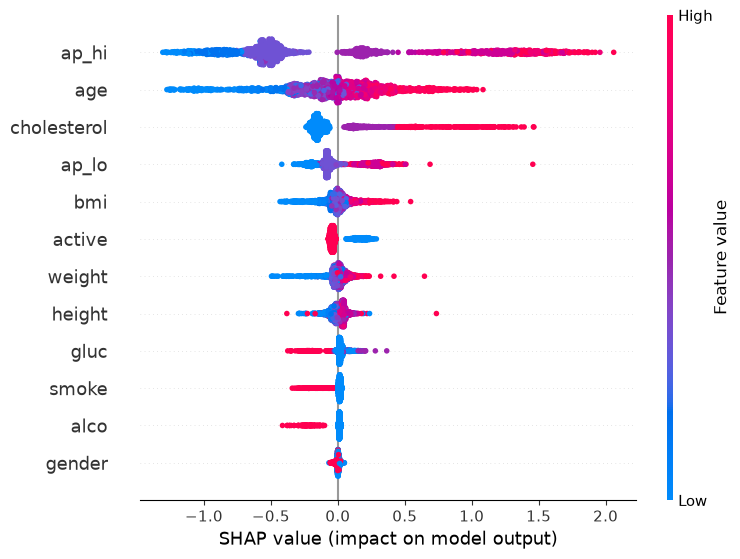

In [85]:
# ============================================================
# SHAP BEESWARM PLOT
# ============================================================

shap.plots.beeswarm(
    shap_values,
    max_display=12
)

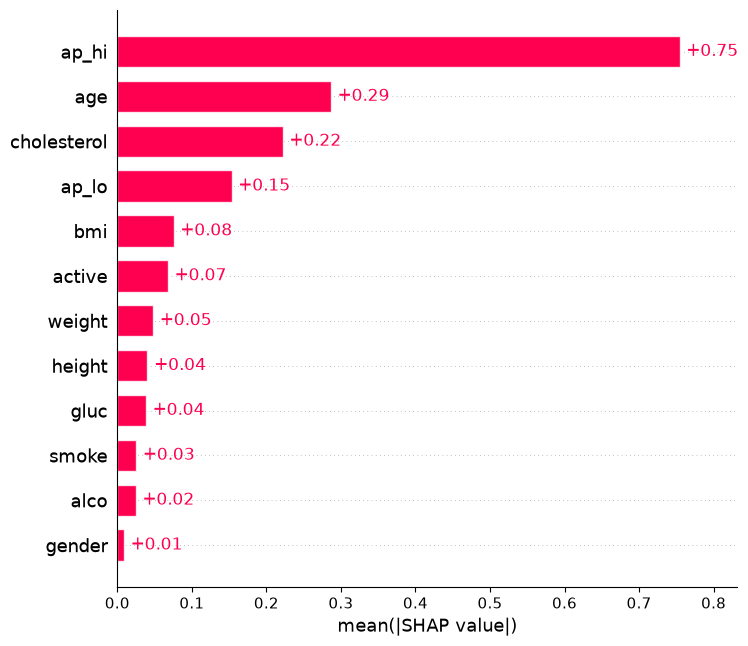

In [86]:
# ============================================================
# SHAP GLOBAL FEATURE IMPORTANCE
# ============================================================

shap.plots.bar(
    shap_values,
    max_display=12
)

In [87]:
# ============================================================
# SHAP LOCAL EXPLANATION — INDIVIDUAL PATIENT
# ============================================================

# Find a test patient with a relatively high predicted probability
patient_position = final_prob.argmax()

patient = X_test.iloc[[patient_position]]

patient_probability = xgb_model.predict_proba(patient)[0, 1]
patient_prediction = xgb_model.predict(patient)[0]

print("Patient position in test set:", patient_position)
print()
print("Patient characteristics:")
display(patient)

print("\nPredicted class:", patient_prediction)
print(f"Predicted cardiovascular disease probability: {patient_probability:.2%}")

Patient position in test set: 749

Patient characteristics:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi
38064,43.485284,1,1.86,130.0,150.0,110.0,1,0,0,0,0,37.576598



Predicted class: 1
Predicted cardiovascular disease probability: 94.11%


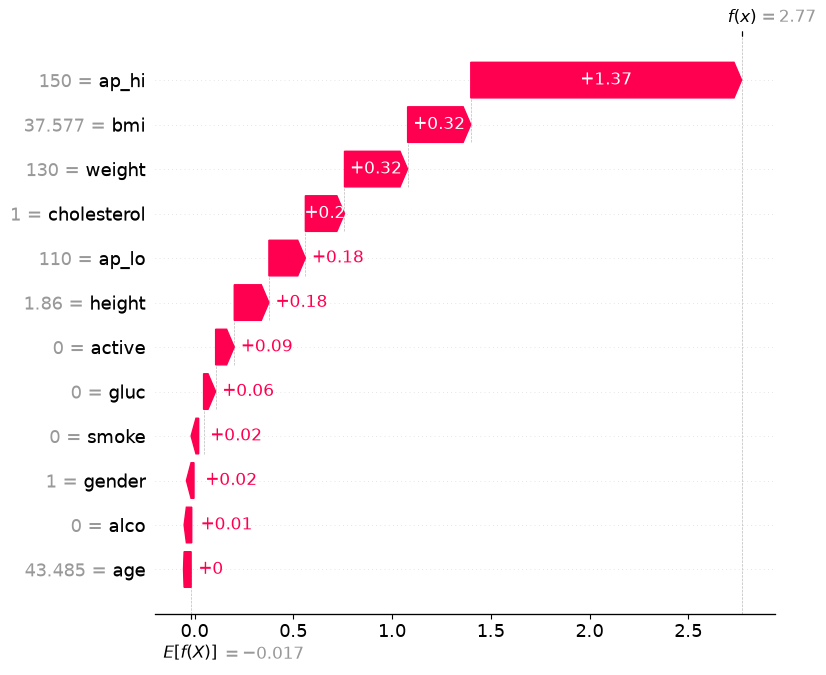

In [88]:
# ============================================================
# SHAP WATERFALL PLOT — INDIVIDUAL PATIENT
# ============================================================

# Explain this specific patient
patient_shap = explainer(patient)

# Display local explanation
shap.plots.waterfall(
    patient_shap[0],
    max_display=12
)

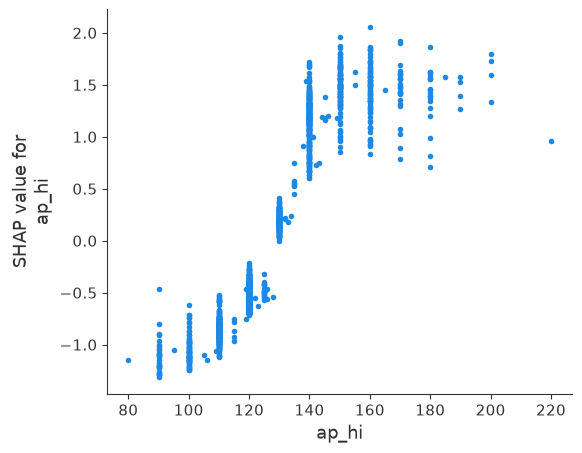

In [89]:
# ============================================================
# SHAP DEPENDENCE PLOT — SYSTOLIC BLOOD PRESSURE
# ============================================================

shap.dependence_plot(
    "ap_hi",
    shap_values.values,
    X_shap,
    interaction_index=None
)

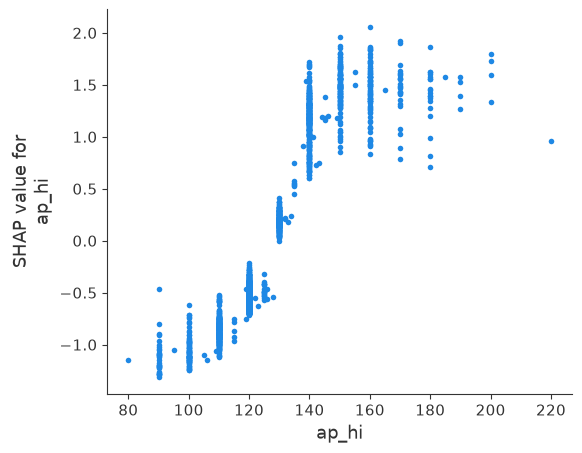

In [90]:
# ============================================================
# SHAP DEPENDENCE PLOT — SYSTOLIC BLOOD PRESSURE
# ============================================================

shap.dependence_plot(
    "ap_hi",
    shap_values.values,
    X_shap,
    interaction_index=None
)

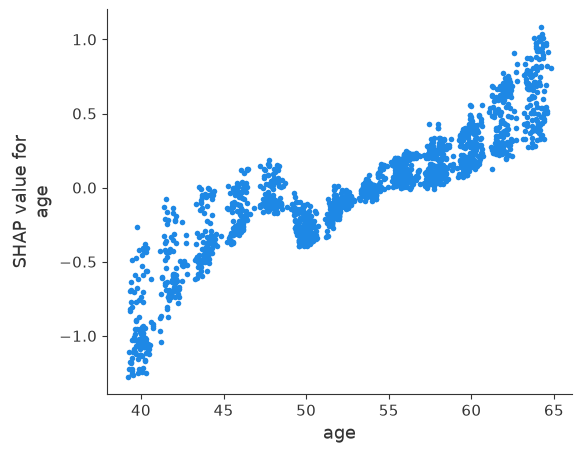

In [91]:
# ============================================================
# SHAP DEPENDENCE PLOT — AGE
# ============================================================

shap.dependence_plot(
    "age",
    shap_values.values,
    X_shap,
    interaction_index=None
)

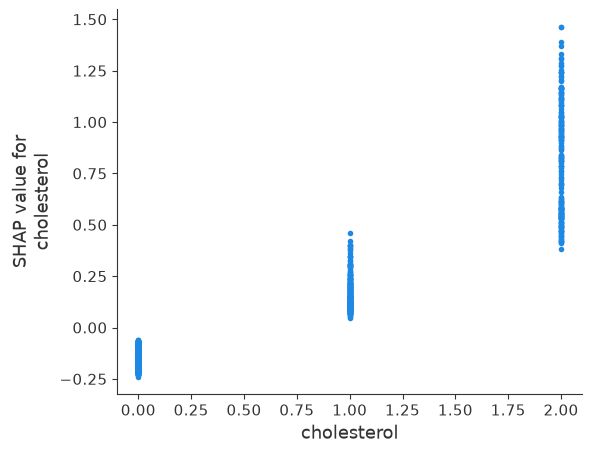

In [92]:
# ============================================================
# SHAP DEPENDENCE PLOT — CHOLESTEROL
# ============================================================

shap.dependence_plot(
    "cholesterol",
    shap_values.values,
    X_shap,
    interaction_index=None
)

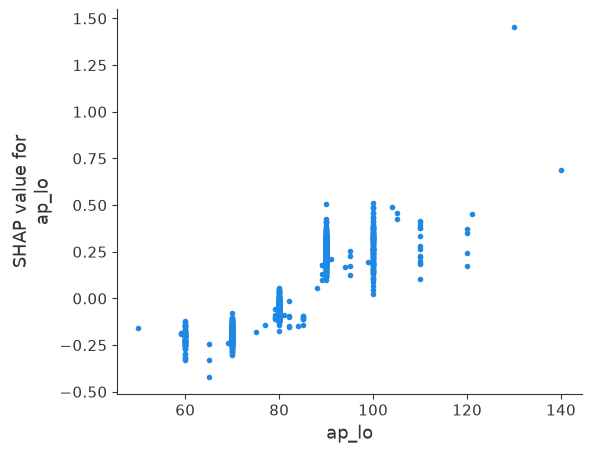

In [93]:
# ============================================================
# SHAP DEPENDENCE PLOT — DIASTOLIC BLOOD PRESSURE
# ============================================================

shap.dependence_plot(
    "ap_lo",
    shap_values.values,
    X_shap,
    interaction_index=None
)

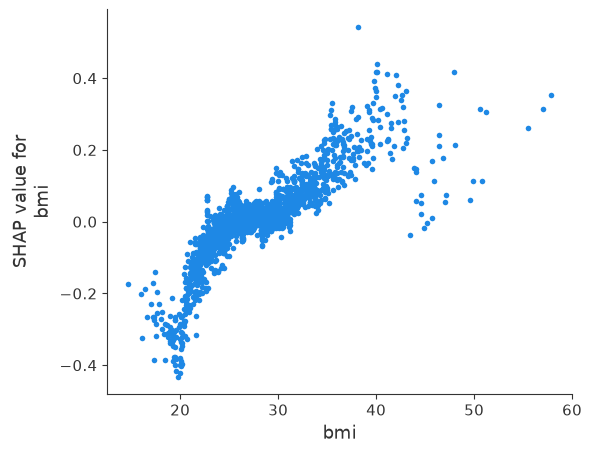

In [94]:
# ============================================================
# SHAP DEPENDENCE PLOT — BMI
# ============================================================

shap.dependence_plot(
    "bmi",
    shap_values.values,
    X_shap,
    interaction_index=None
)

## 13. Model Saving and Reproducibility

The final trained XGBoost model is serialized using `joblib` so that it can be loaded and reused without retraining.

The saved model is reloaded and its predictions are compared with those of the original in-memory model. Both class predictions and predicted probabilities are confirmed to be identical.

A separate JSON metadata file is also created to preserve the feature list, target variable, classification threshold, evaluation metrics, and training/test dataset sizes.

In [95]:
# ============================================================
# SAVE FINAL TRAINED XGBOOST MODEL
# ============================================================

import joblib

joblib.dump(xgb_model, "cardio_xgboost_model.pkl")

print("Final XGBoost model saved successfully.")

Final XGBoost model saved successfully.


In [96]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

import joblib
import numpy as np

# Load the model we just saved
loaded_model = joblib.load("cardio_xgboost_model.pkl")

# Predictions from original model
original_predictions = xgb_model.predict(X_test)
original_probabilities = xgb_model.predict_proba(X_test)[:, 1]

# Predictions from reloaded model
loaded_predictions = loaded_model.predict(X_test)
loaded_probabilities = loaded_model.predict_proba(X_test)[:, 1]

# Verify they are identical
print(
    "Class predictions identical:",
    np.array_equal(original_predictions, loaded_predictions)
)

print(
    "Probabilities identical:",
    np.allclose(original_probabilities, loaded_probabilities)
)

print("Loaded model type:", type(loaded_model))

Class predictions identical: True
Probabilities identical: True
Loaded model type: <class 'xgboost.sklearn.XGBClassifier'>


In [97]:
# ============================================================
# CALCULATE FINAL METRICS AND SAVE MODEL METADATA
# ============================================================

import json

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Recalculate final predictions
final_pred = xgb_model.predict(X_test)
final_prob = xgb_model.predict_proba(X_test)[:, 1]

# Recalculate final evaluation metrics
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_auc = roc_auc_score(y_test, final_prob)

# Create metadata
model_metadata = {
    "model_name": "XGBoost Cardiovascular Risk Classifier",
    "target": "cardio",
    "features": X_train.columns.tolist(),
    "default_threshold": 0.50,
    "test_accuracy": float(final_accuracy),
    "test_precision": float(final_precision),
    "test_recall": float(final_recall),
    "test_f1": float(final_f1),
    "test_roc_auc": float(final_auc),
    "training_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0])
}

# Save metadata
with open("cardio_model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Model metadata saved successfully.")
print()
print(json.dumps(model_metadata, indent=4))

Model metadata saved successfully.

{
    "model_name": "XGBoost Cardiovascular Risk Classifier",
    "target": "cardio",
    "features": [
        "age",
        "gender",
        "height",
        "weight",
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc",
        "smoke",
        "alco",
        "active",
        "bmi"
    ],
    "default_threshold": 0.5,
    "test_accuracy": 0.7344920369427678,
    "test_precision": 0.7551350477114669,
    "test_recall": 0.6860123420511314,
    "test_f1": 0.7189160058511048,
    "test_roc_auc": 0.802215943794141,
    "training_rows": 55003,
    "test_rows": 13751
}


In [98]:
import os

files_to_check = [
    "cardio_xgboost_model.pkl",
    "cardio_model_metadata.json"
]

for file in files_to_check:
    print(file, "->", os.path.exists(file))

cardio_xgboost_model.pkl -> True
cardio_model_metadata.json -> True


## 14. Project Summary and Conclusions

This project developed an end-to-end machine-learning workflow for cardiovascular disease prediction using 70,000 original patient records.

After data-quality investigation and reproducible cleaning, 68,754 observations were retained for modeling. Logistic Regression, Random Forest, and XGBoost models were compared using held-out test performance and five-fold cross-validation.

XGBoost was selected as the final model because it achieved the strongest overall ROC-AUC and stable cross-validation performance.

The project also demonstrated that predictive performance alone is not sufficient. Threshold analysis showed the trade-off between false positives and false negatives, while SHAP explainability provided insight into both population-level and individual predictions.

Systolic blood pressure, age, cholesterol, diastolic blood pressure, and BMI emerged as important drivers in the explainability analysis.

### Limitations

- The model is based on a single observational dataset.
- The cleaning thresholds are rule-based and were not clinically validated.
- No external validation dataset was used.
- Model predictions should not be interpreted as medical diagnoses.
- Further work could investigate calibration, external validation, additional feature engineering, and clinically informed threshold selection.

### Final Outcome

The project successfully produced:

- A reproducible cleaned modeling dataset
- Multiple evaluated machine-learning models
- A selected XGBoost classifier
- Cross-validation and hyperparameter analysis
- Threshold-performance analysis
- Global and individual SHAP explanations
- A serialized trained model
- Model metadata for reproducibility

The resulting workflow demonstrates a complete machine-learning lifecycle from raw data investigation through model interpretation and preservation.

In [99]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("CARDIOVASCULAR RISK PREDICTION - FINAL SUMMARY")
print("=" * 55)

print("\nDataset:")
print("Original records: 70,000")
print("Replication-cleaned records: 68,754")

print("\nSelected Model:")
print("XGBoost Classifier")

print("\nFinal Test Metrics:")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1 Score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_auc:.4f}")

print("\nTraining / Test Split:")
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

print("\nTop SHAP Features:")
print("1. Systolic blood pressure (ap_hi)")
print("2. Age")
print("3. Cholesterol")
print("4. Diastolic blood pressure (ap_lo)")
print("5. BMI")

print("\nSaved Artifacts:")
print("- cardio_xgboost_model.pkl")
print("- cardio_model_metadata.json")

print("\nStatus: Model training, evaluation, explainability, and saving complete.")

CARDIOVASCULAR RISK PREDICTION - FINAL SUMMARY

Dataset:
Original records: 70,000
Replication-cleaned records: 68,754

Selected Model:
XGBoost Classifier

Final Test Metrics:
Accuracy:  0.7345
Precision: 0.7551
Recall:    0.6860
F1 Score:  0.7189
ROC-AUC:   0.8022

Training / Test Split:
Training rows: 55003
Test rows: 13751

Top SHAP Features:
1. Systolic blood pressure (ap_hi)
2. Age
3. Cholesterol
4. Diastolic blood pressure (ap_lo)
5. BMI

Saved Artifacts:
- cardio_xgboost_model.pkl
- cardio_model_metadata.json

Status: Model training, evaluation, explainability, and saving complete.
